In [1]:
import numpy as np
import skimage
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import pandas as pd
from skimage.filters.rank import entropy
from skimage.morphology import disk

In [2]:
file_list = glob.glob('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/*/Carboplatin.tiff')
file_list = pd.DataFrame(file_list,columns = ['path'])
file_list['acquisition_ID'] = file_list.path.str.split('/').str[-2]
file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()

biosamples_path = '~/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)

In [3]:
file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient

In [ ]:
def frac_zeros_image(file):
    '''Return the fraction of pixels ==0'''
    img = skimage.io.imread(file)    
    return np.count_nonzero(img==0)/(img.shape[0]*img.shape[1])
def mean_entropy(file):
    img = skimage.io.imread(file)
    img = skimage.exposure.rescale_intensity(img,in_range=(0, 1))
    return entropy(img,disk(5)).mean()
file_list['empty_pixel_frac'] = file_list.path.map(frac_zeros_image)
file_list['mean_entropy'] = file_list.path.map(mean_entropy)


/home/giuseppe/anaconda3/lib/python3.9/site-packages/pandas/core/algorithms.py:1814: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return lib.map_infer(values, mapper, convert=convert)


In [ ]:
a = file_list[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','empty_pixel_frac','mean_entropy']].sort_values('mean_entropy',ascending=False)
plt.scatter(a.empty_pixel_frac ,a.mean_entropy,color = np.where(a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE','red','green'),s = 0.5)
a

In [ ]:
file_list[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','mean_entropy']].sort_values('mean_entropy',ascending=False).to_csv('Carboplatin_acquisition_ID.csv')

In [134]:

img = skimage.io.imread(file_list.path[763])
img = skimage.exposure.rescale_intensity(img,in_range=(0, 1))

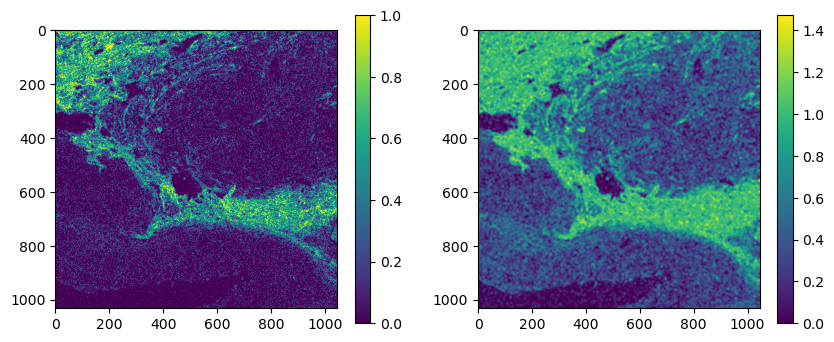

In [135]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
f = ax0.imshow(img)
fig.colorbar(f, ax=ax0)
f = ax1.imshow(entropy(img,disk(5)))
fig.colorbar(f, ax=ax1)

In [115]:
skimage.io.imread(file_list.path[81])==skimage.io.imread(file_list.path[226])


array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])